In [ ]:
# ============================================================
# CELL 1 — Upload & Ekstrak Dataset
# ============================================================
from google.colab import files
import os, zipfile, shutil

uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
print(f'\n nama file: {zip_filename}')

EXTRACT_DIR = '/content/dataset_raw'
print('Mengekstrak ZIP...')
with zipfile.ZipFile(zip_filename, 'r') as zf:
    zf.extractall(EXTRACT_DIR)
print('Ekstraksi selesai')

for root, dirs, files_ in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 2:
        print(f'{indent}  └─ {len(files_)} file')

Saving DATASET SAMPAH.zip to DATASET SAMPAH (1).zip

 nama file: DATASET SAMPAH (1).zip
Mengekstrak ZIP...
Ekstraksi selesai
dataset_raw/
  DATASET/
    TEST/
      └─ 0 file
      O/
      R/
    TRAIN/
      └─ 0 file
      O/
      R/


In [ ]:
# ============================================================
# CELL 2 — Split Train/Val (80/20) & Siapkan Test
# ============================================================
import random

BASE_DIR  = os.path.join(EXTRACT_DIR, 'DATASET')
TRAIN_SRC = os.path.join(BASE_DIR, 'TRAIN')
TEST_DIR  = os.path.join(BASE_DIR, 'TEST')

TRAIN_DIR  = '/content/data/train'
VAL_DIR    = '/content/data/val'
TEST_FINAL = '/content/data/test'

VAL_RATIO   = 0.20
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

CLASS_MAP = {'O': 'organik', 'R': 'anorganik'}

def split_and_copy(src_dir, train_dst, val_dst, val_ratio, class_map):
    for cls_code, cls_name in class_map.items():
        src = os.path.join(src_dir, cls_code)
        all_files = [f for f in os.listdir(src)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(all_files)
        n_val       = int(len(all_files) * val_ratio)
        val_files   = all_files[:n_val]
        train_files = all_files[n_val:]
        for split_files, dst_root in [(train_files, train_dst), (val_files, val_dst)]:
            dst = os.path.join(dst_root, cls_name)
            os.makedirs(dst, exist_ok=True)
            for fname in split_files:
                shutil.copy2(os.path.join(src, fname), os.path.join(dst, fname))
        print(f'  [{cls_code}→{cls_name}] train: {len(train_files)} | val: {len(val_files)}')

def copy_test(src_dir, dst_dir, class_map):
    for cls_code, cls_name in class_map.items():
        src = os.path.join(src_dir, cls_code)
        dst = os.path.join(dst_dir, cls_name)
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print(f'  [{cls_code}→{cls_name}] test: {len(os.listdir(dst))}')

print('📂 Membuat split train/val/test...')
split_and_copy(TRAIN_SRC, TRAIN_DIR, VAL_DIR, VAL_RATIO, CLASS_MAP)
copy_test(TEST_DIR, TEST_FINAL, CLASS_MAP)

print('\n✅ Struktur data siap:')
for split, path in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_FINAL)]:
    classes = os.listdir(path)
    total   = sum(len(os.listdir(os.path.join(path, c))) for c in classes)
    print(f'  {split:5s}: {total:6d} gambar → {classes}')

📂 Membuat split train/val/test...
  [O→organik] train: 10072 | val: 2518
  [R→anorganik] train: 8003 | val: 2000
  [O→organik] test: 1401
  [R→anorganik] test: 1112

✅ Struktur data siap:
  train:  18075 gambar → ['organik', 'anorganik']
  val  :   4518 gambar → ['organik', 'anorganik']
  test :   2513 gambar → ['organik', 'anorganik']


In [ ]:
# ============================================================
# CELL 3 — Konfigurasi Hyperparameter
# ============================================================
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS        = 30
LEARNING_RATE = 1e-3

OUTPUT_DIR      = '/content/output'
KERAS_PATH      = os.path.join(OUTPUT_DIR, 'waste_classifier.keras')
SAVEDMODEL_PATH = os.path.join(OUTPUT_DIR, 'waste_classifier_savedmodel')
LOG_CSV_PATH    = os.path.join(OUTPUT_DIR, 'training_log.csv')
META_PATH       = os.path.join(OUTPUT_DIR, 'model_metadata.json')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'IMG_SIZE={IMG_SIZE} | BATCH={BATCH_SIZE} | EPOCHS={EPOCHS} | LR={LEARNING_RATE}')

IMG_SIZE=(224, 224) | BATCH=32 | EPOCHS=30 | LR=0.001


In [ ]:
# ============================================================
# CELL 4 — Import Library
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import csv, json, time
from IPython.display import clear_output

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# CELL 5 — Load & Augmentasi Dataset
# ============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=True
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_FINAL, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'Class indices : {train_gen.class_indices}')
print(f'Train : {train_gen.samples} | Val : {val_gen.samples} | Test : {test_gen.samples}')

Found 18075 images belonging to 2 classes.
Found 4518 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
Class indices : {'anorganik': 0, 'organik': 1}
Train : 18075 | Val : 4518 | Test : 2513


/tmp/ipykernel_1381/1964709997.py:15: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1381/1964709997.py:15: UserWarning: Glyph 129524 (\N{LOTION BOTTLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129524 (\N{LOTION BOTTLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


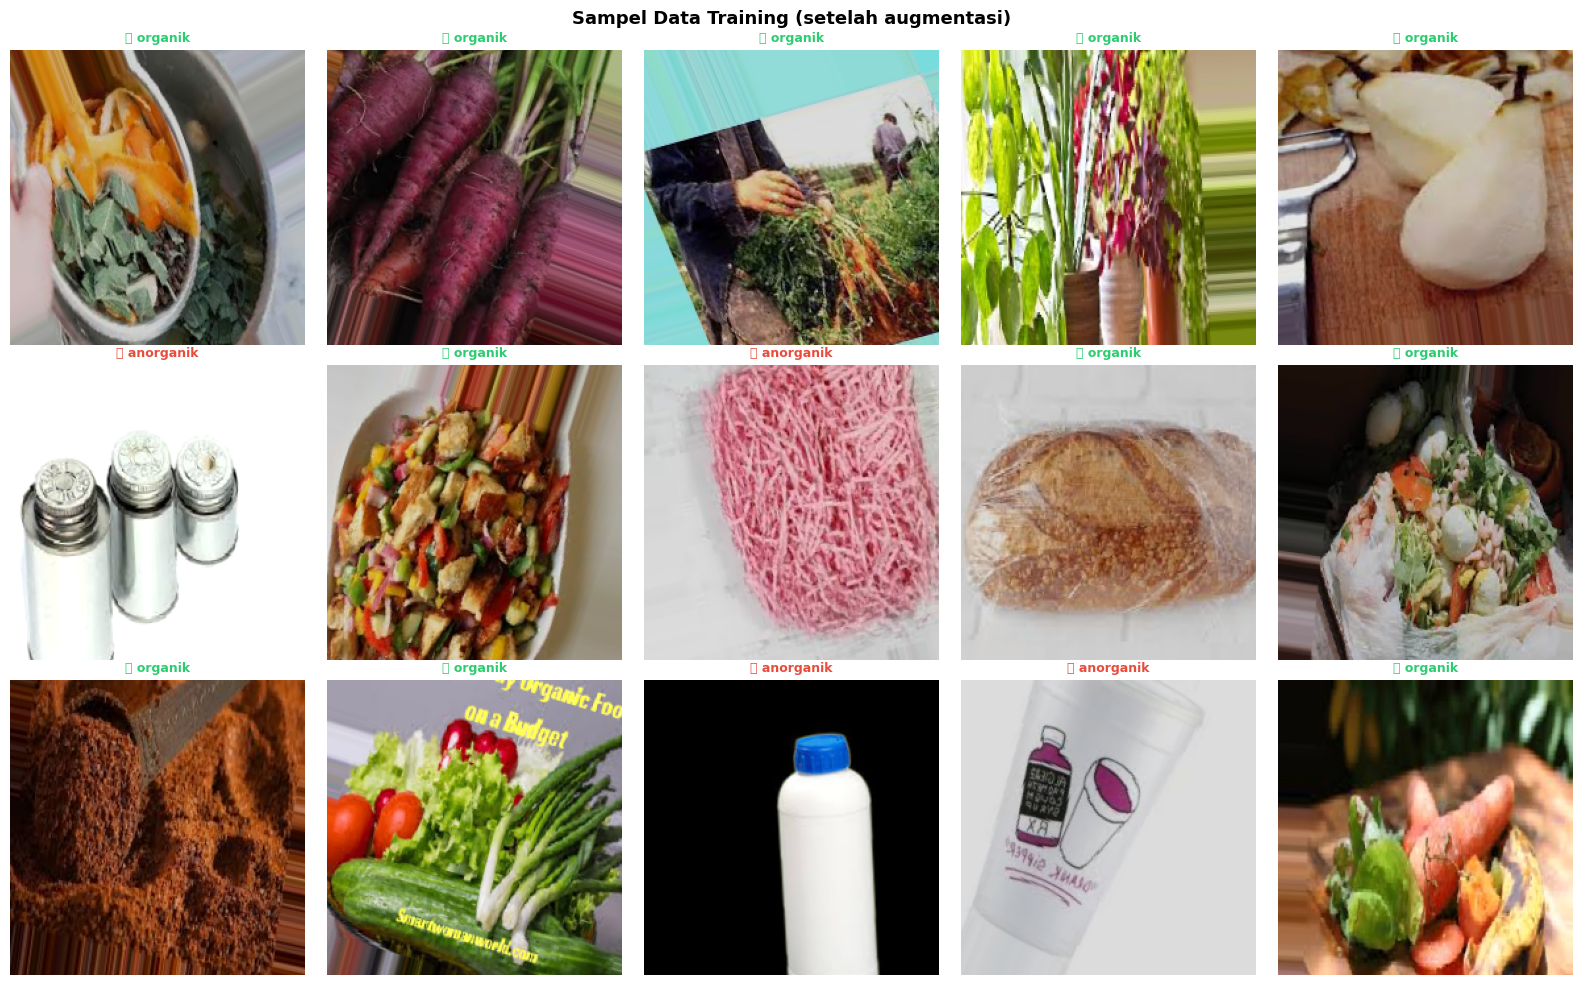

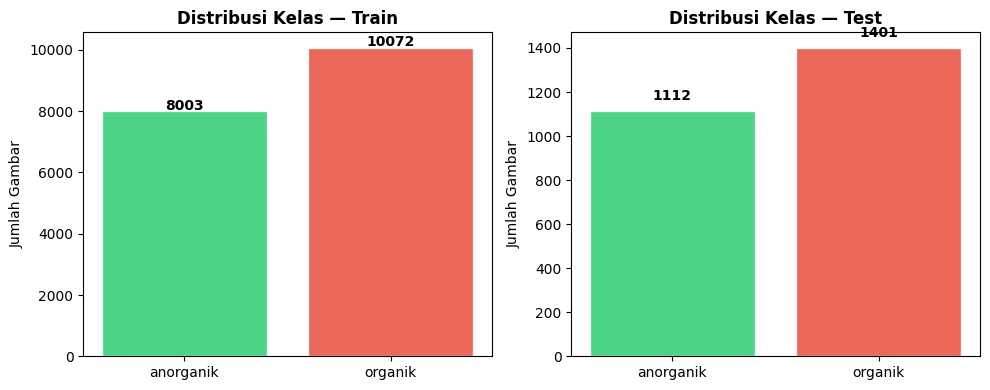

In [ ]:
# ============================================================
# CELL 6 — Visualisasi Sampel & Distribusi Kelas
# ============================================================
images, labels = next(train_gen)
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
        lbl   = CLASS_NAMES[int(labels[i])]
        color = '#2ecc71' if lbl == 'organik' else '#e74c3c'
        emoji = '🌿' if lbl == 'organik' else '🧴'
        ax.set_title(f'{emoji} {lbl}', fontsize=9, color=color, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sampel Data Training (setelah augmentasi)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (gen, title) in zip(axes, [(train_gen, 'Train'), (test_gen, 'Test')]):
    counts = [sum(gen.classes == i) for i in range(len(CLASS_NAMES))]
    bars = ax.bar(CLASS_NAMES, counts, color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='white')
    ax.set_title(f'Distribusi Kelas — {title}', fontweight='bold')
    ax.set_ylabel('Jumlah Gambar')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 7 — Custom Layer: ChannelAttention (SE-Block)
# ============================================================
class ChannelAttention(layers.Layer):
    """
    Squeeze-and-Excitation Block
    Memfokuskan model pada channel fitur paling relevan
    untuk membedakan sampah organik vs anorganik.
    """
    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels   = input_shape[-1]
        bottleneck = max(1, channels // self.reduction_ratio)
        self.gap     = layers.GlobalAveragePooling2D()
        self.fc1     = layers.Dense(bottleneck, activation='relu',   use_bias=False)
        self.fc2     = layers.Dense(channels,   activation='sigmoid', use_bias=False)
        self.reshape = layers.Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, inputs, training=None):
        squeezed = self.gap(inputs)
        excited  = self.fc2(self.fc1(squeezed))
        scale    = self.reshape(excited)
        return inputs * scale

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'reduction_ratio': self.reduction_ratio})
        return cfg


dummy = tf.random.normal((2, 14, 14, 64))
out   = ChannelAttention(reduction_ratio=16)(dummy)
print(f'✅ ChannelAttention OK — input: {dummy.shape} → output: {out.shape}')

✅ ChannelAttention OK — input: (2, 14, 14, 64) → output: (2, 14, 14, 64)


In [ ]:
# ============================================================
# CELL 8 — Custom Callback: DetailedTrainingLogger
# ============================================================
class DetailedTrainingLogger(keras.callbacks.Callback):
    """
    Menyimpan metrik per epoch ke CSV, menampilkan grafik live,
    dan mencetak ringkasan akhir training.
    """
    def __init__(self, csv_path, plot_every=5):
        super().__init__()
        self.csv_path   = csv_path
        self.plot_every = plot_every
        self.hist = {'epoch': [], 'loss': [], 'accuracy': [],
                     'val_loss': [], 'val_accuracy': [], 'epoch_time_s': []}
        self._t0 = None
        with open(csv_path, 'w', newline='') as f:
            csv.DictWriter(f, fieldnames=list(self.hist.keys())).writeheader()

    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs    = logs or {}
        elapsed = time.time() - self._t0
        total   = self.params.get('epochs', 0)
        eta_s   = (total - epoch - 1) * elapsed

        row = {
            'epoch'        : epoch + 1,
            'loss'         : round(logs.get('loss', 0), 4),
            'accuracy'     : round(logs.get('accuracy', 0), 4),
            'val_loss'     : round(logs.get('val_loss', 0), 4),
            'val_accuracy' : round(logs.get('val_accuracy', 0), 4),
            'epoch_time_s' : round(elapsed, 1)
        }
        for k, v in row.items():
            self.hist[k].append(v)

        with open(self.csv_path, 'a', newline='') as f:
            csv.DictWriter(f, fieldnames=list(self.hist.keys())).writerow(row)

        eta_str = f'{eta_s/60:.1f} mnt' if eta_s > 0 else '-'
        print(f'  📝 [{epoch+1:3d}/{total}] '
              f'loss:{row["loss"]:.4f}  acc:{row["accuracy"]:.4f}  '
              f'val_loss:{row["val_loss"]:.4f}  val_acc:{row["val_accuracy"]:.4f}  '
              f'⏱{elapsed:.0f}s  ETA:{eta_str}')

        if (epoch + 1) % self.plot_every == 0:
            self._plot()

    def _plot(self):
        clear_output(wait=True)
        ep  = self.hist['epoch']
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        fig.suptitle('📊 Live Training Monitor', fontsize=13, fontweight='bold')

        axes[0].plot(ep, self.hist['accuracy'],     'b-o', ms=3, label='Train')
        axes[0].plot(ep, self.hist['val_accuracy'], 'r-o', ms=3, label='Val')
        axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].set_ylim([0, 1])

        axes[1].plot(ep, self.hist['loss'],     'b-o', ms=3, label='Train')
        axes[1].plot(ep, self.hist['val_loss'], 'r-o', ms=3, label='Val')
        axes[1].set_title('Loss'); axes[1].legend()

        axes[2].bar(ep, self.hist['epoch_time_s'], color='steelblue', alpha=0.7)
        axes[2].set_title('Waktu per Epoch (detik)')

        for ax in axes: ax.set_xlabel('Epoch')
        plt.tight_layout(); plt.show()

    def on_train_end(self, logs=None):
        best_acc   = max(self.hist['val_accuracy'])
        best_epoch = self.hist['val_accuracy'].index(best_acc) + 1
        total_time = sum(self.hist['epoch_time_s'])
        print('\n' + '='*62)
        print('✅ TRAINING SELESAI')
        print(f'   Best Val Accuracy : {best_acc:.4f}  (epoch {best_epoch})')
        print(f'   Total Waktu       : {total_time/60:.1f} menit')
        print(f'   Log tersimpan     : {self.csv_path}')
        print('='*62)
        self._plot()


print('✅ DetailedTrainingLogger berhasil didefinisikan')

✅ DetailedTrainingLogger berhasil didefinisikan


In [ ]:
# ============================================================
# CELL 9 — Model Subclassing: WasteClassifier
# ============================================================
class WasteClassifier(Model):
    """
    Arsitektur Model Subclassing untuk klasifikasi biner
    sampah Organik vs Anorganik.

    Backbone  : EfficientNetB0 (ImageNet, frozen → fine-tune)
    Attention : 2x ChannelAttention (Custom Layer)
    Pooling   : Dual GAP + GMP
    Head      : Dense(256) → Dropout → Dense(64) → Dropout → Sigmoid
    """
    def __init__(self, img_size=(224, 224), dropout_rate=0.4, **kwargs):
        super().__init__(**kwargs)
        self.img_size     = img_size
        self.dropout_rate = dropout_rate

        self.backbone = tf.keras.applications.EfficientNetB0(
            input_shape=(*img_size, 3), include_top=False, weights='imagenet'
        )
        self.backbone.trainable = False

        self.attn1 = ChannelAttention(reduction_ratio=16, name='attention_1')
        self.attn2 = ChannelAttention(reduction_ratio=8,  name='attention_2')

        self.gap = layers.GlobalAveragePooling2D()
        self.gmp = layers.GlobalMaxPooling2D()
        self.bn  = layers.BatchNormalization()

        self.d1  = layers.Dense(256, activation='relu')
        self.dr1 = layers.Dropout(dropout_rate)
        self.d2  = layers.Dense(64,  activation='relu')
        self.dr2 = layers.Dropout(dropout_rate / 2)
        self.out = layers.Dense(1, activation='sigmoid', name='output')

    def call(self, inputs, training=None):
        x = self.backbone(inputs, training=False)
        x = self.attn1(x, training=training)
        x = self.attn2(x, training=training)
        x = self.gap(x) + self.gmp(x)
        x = self.bn(x, training=training)
        x = self.dr1(self.d1(x), training=training)
        x = self.dr2(self.d2(x), training=training)
        return self.out(x)

    def unfreeze_top(self, n=30):
        self.backbone.trainable = True
        for layer in self.backbone.layers[:-n]:
            layer.trainable = False
        trainable = sum(1 for l in self.backbone.layers if l.trainable)
        print(f'✅ {trainable} layer backbone aktif untuk fine-tuning')

    def get_config(self):
        return {'img_size': self.img_size, 'dropout_rate': self.dropout_rate}


model = WasteClassifier(img_size=IMG_SIZE, name='WasteClassifier')
model.build((None, *IMG_SIZE, 3))
model.summary()

print('\n🔍 Custom layers terpasang:')
for l in model.layers:
    if isinstance(l, ChannelAttention):
        print(f'   ✅ {l.name} (ChannelAttention, reduction={l.reduction_ratio})')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'WasteClassifier', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "WasteClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_1 (ChannelAttention)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_2 (ChannelAttention)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ ?                      │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)


🔍 Custom layers terpasang:
   ✅ attention_1 (ChannelAttention, reduction=16)
   ✅ attention_2 (ChannelAttention, reduction=8)


In [ ]:
# ============================================================
# CELL 10 — Compile Model
# ============================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print('✅ Compiled — loss: binary_crossentropy | metrics: acc, AUC, precision, recall')

✅ Compiled — loss: binary_crossentropy | metrics: acc, AUC, precision, recall


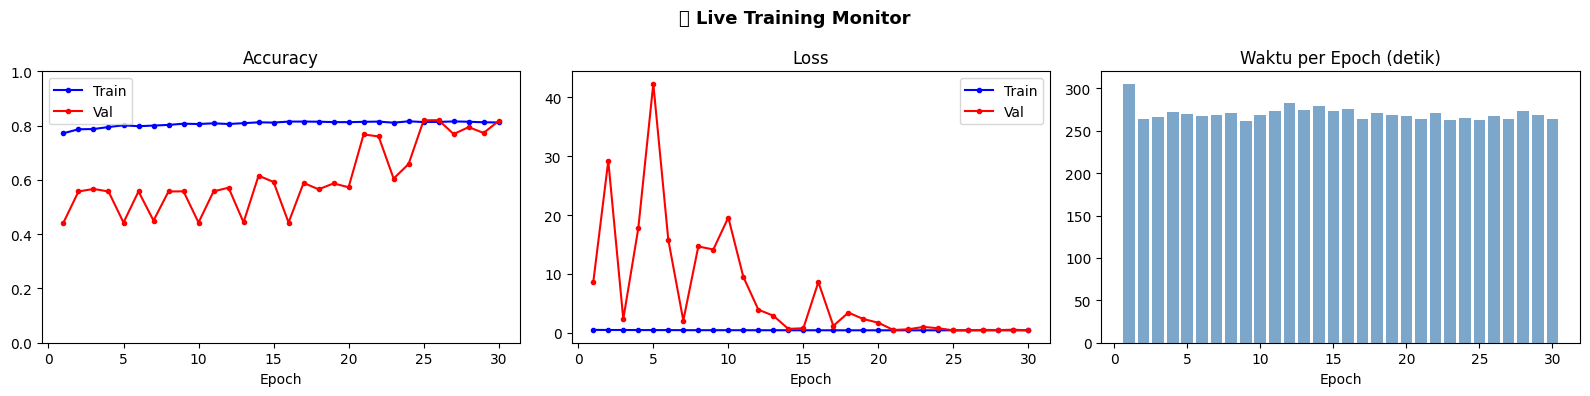

Restoring model weights from the end of the best epoch: 30.


In [ ]:
# ============================================================
# CELL 11 — Training Fase 1 (Backbone Frozen)
# ============================================================
logger1 = DetailedTrainingLogger(csv_path=LOG_CSV_PATH, plot_every=5)

callbacks1 = [
    logger1,
    ModelCheckpoint(KERAS_PATH, monitor='val_accuracy', save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

print('🚀 Fase 1 — Backbone frozen, hanya head yang dilatih')
print('='*62)

history1 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks1,
    verbose=0
)

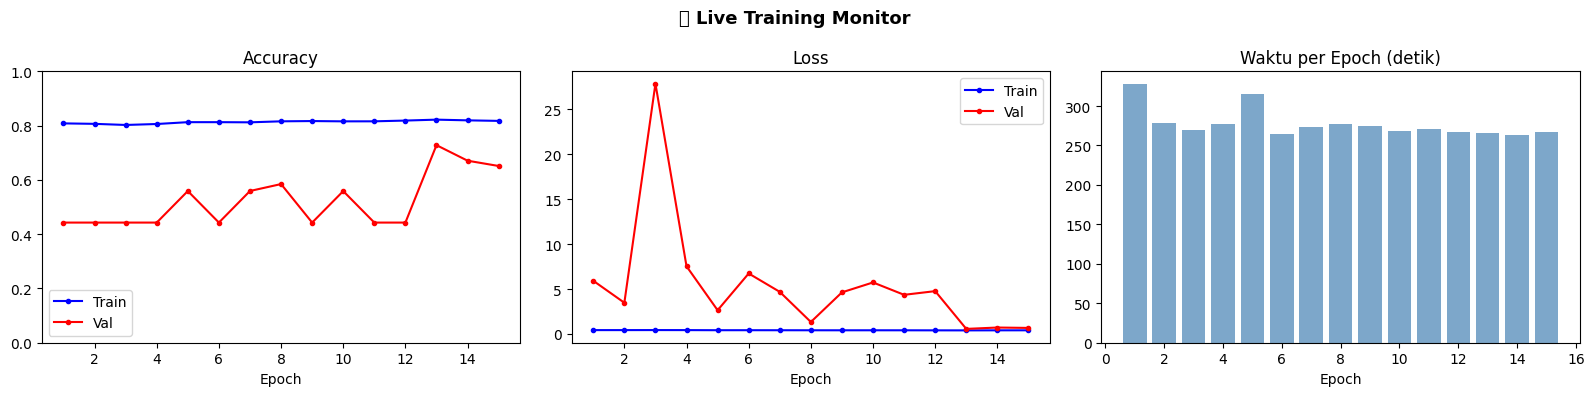

Restoring model weights from the end of the best epoch: 13.


In [ ]:
# ============================================================
# CELL 12 — Fine-Tuning Fase 2 (Unfreeze Top 30 Layer)
# ============================================================
model.unfreeze_top(n=30)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE / 10),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

log_ft  = LOG_CSV_PATH.replace('.csv', '_finetune.csv')
logger2 = DetailedTrainingLogger(csv_path=log_ft, plot_every=3)

callbacks2 = [
    logger2,
    ModelCheckpoint(KERAS_PATH, monitor='val_accuracy', save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8, verbose=1)
]

print('🔧 Fase 2 — Fine-tuning top 30 layer backbone')
print('='*62)

history2 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=callbacks2,
    verbose=0
)

In [ ]:
# ============================================================
# CELL 13 — Evaluasi pada Test Set
# ============================================================
CUSTOM_OBJECTS = {
    'ChannelAttention': ChannelAttention,
    'WasteClassifier' : WasteClassifier
}

best_model = tf.keras.models.load_model(KERAS_PATH, custom_objects=CUSTOM_OBJECTS)

results = best_model.evaluate(test_gen, verbose=1)
print('\n📊 Test Set Results:')
for name, val in zip(best_model.metrics_names, results):
    print(f'   {name:12s}: {val:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 386ms/step - accuracy: 0.7847 - auc: 0.9131 - loss: 0.4525 - precision: 0.9274 - recall: 0.6660

📊 Test Set Results:
   loss        : 0.4525
   compile_metrics: 0.7847


79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step

📋 Classification Report:
              precision    recall  f1-score   support

   anorganik       0.69      0.93      0.79      1112
     organik       0.93      0.67      0.78      1401

    accuracy                           0.78      2513
   macro avg       0.81      0.80      0.78      2513
weighted avg       0.82      0.78      0.78      2513



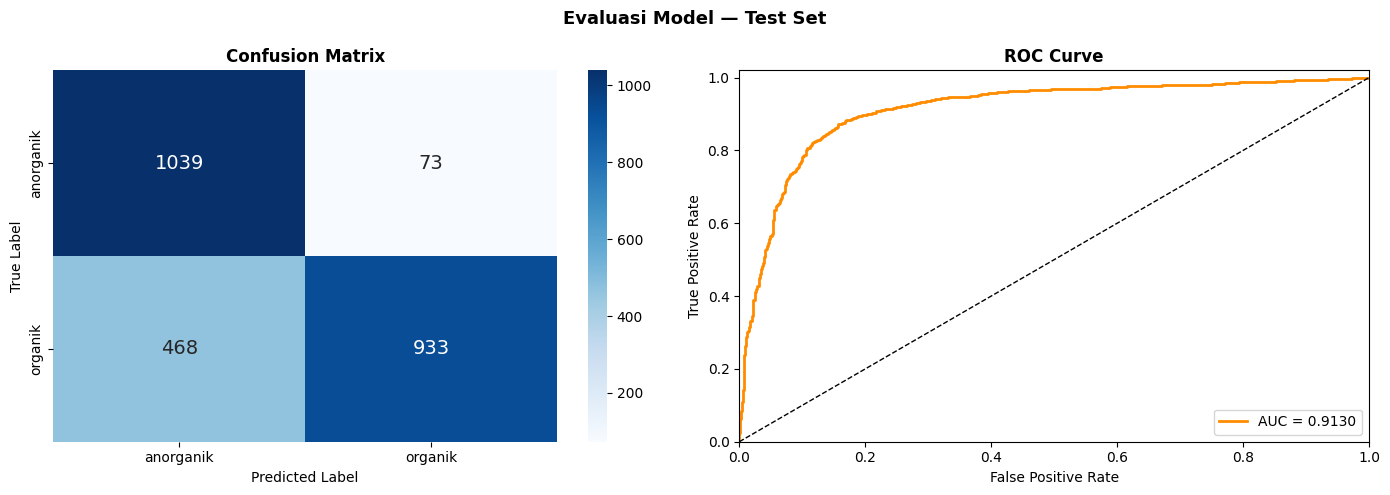

In [ ]:
# ============================================================
# CELL 14 — Confusion Matrix & ROC Curve
# ============================================================
test_gen.reset()
y_prob = best_model.predict(test_gen, verbose=1).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes

print('\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')

plt.suptitle('Evaluasi Model — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 15 — Simpan & Ekspor Model
# ============================================================
# .keras sudah tersimpan via ModelCheckpoint
print(f'✅ .keras      : {KERAS_PATH}')

# SavedModel
best_model.export(SAVEDMODEL_PATH)
print(f'✅ SavedModel  : {SAVEDMODEL_PATH}')

# Metadata
metadata = {
    'class_names'  : CLASS_NAMES,
    'class_indices': train_gen.class_indices,
    'img_size'     : list(IMG_SIZE),
    'model_name'   : 'WasteClassifier',
    'backbone'     : 'EfficientNetB0',
    'custom_layers': ['ChannelAttention (SE-Block)'],
    'threshold'    : 0.5,
    'dataset_info' : {
        'train'  : train_gen.samples,
        'val'    : val_gen.samples,
        'test'   : test_gen.samples,
        'classes': {'O': 'organik', 'R': 'anorganik'}
    }
}
with open(META_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'✅ Metadata    : {META_PATH}')

print('\n📁 Semua file output:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        unit = 'MB' if size > 1024**2 else 'KB'
        val  = size/1024**2 if unit == 'MB' else size/1024
        print(f'   {fname} ({val:.1f} {unit})')

✅ .keras      : /content/output/waste_classifier.keras
Saved artifact at '/content/output/waste_classifier_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133224205895824: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133224205894288: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133226630692112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133226630691728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133226630690960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133226630687696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133226630689424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133226630691536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133226630687504: TensorSpec(shape=(), dtype=tf.resource, name=No

In [ ]:
# ============================================================
# CELL 16 — Download Model ke Lokal
# ============================================================
from google.colab import files

files.download(KERAS_PATH)
files.download(META_PATH)
files.download(LOG_CSV_PATH)
print('✅ Download dimulai')

⏳ Memuat model...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Siap. Kelas: ['anorganik', 'organik'] | Threshold: 0.5

📌 Contoh inferensi dari test set:

[Label asli: anorganik]


/tmp/ipykernel_1381/925390052.py:52: UserWarning: Glyph 129524 (\N{LOTION BOTTLE}) missing from font(s) DejaVu Sans.
  plt.axis('off'); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129524 (\N{LOTION BOTTLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


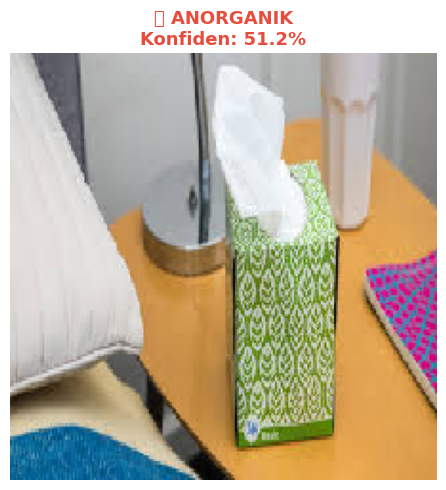

📊 {'anorganik': 0.5122, 'organik': 0.4878}
✅ BENAR — Prediksi: anorganik (51.2%)

[Label asli: organik]


/tmp/ipykernel_1381/925390052.py:52: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.axis('off'); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


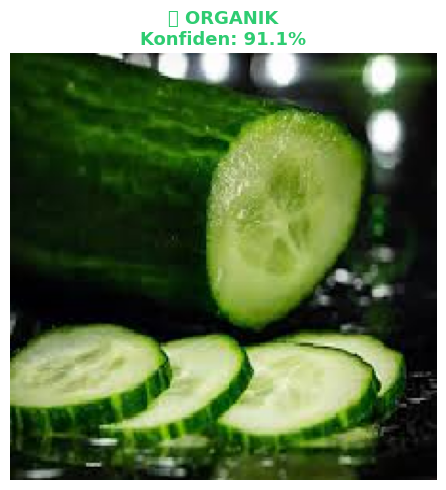

📊 {'anorganik': 0.0887, 'organik': 0.9113}
✅ BENAR — Prediksi: organik (91.1%)


In [ ]:
# ============================================================
# CELL 17 — Inference Pipeline
# ============================================================
from tensorflow.keras.preprocessing import image as keras_image

class WasteInferencePipeline:
    """
    Pipeline Inference Produksi — Deteksi Sampah Organik/Anorganik
    Cara pakai:
        pipeline = WasteInferencePipeline(KERAS_PATH, META_PATH)
        result   = pipeline.predict('/path/gambar.jpg')
    """
    def __init__(self, model_path, metadata_path, threshold=0.5):
        print('⏳ Memuat model...')
        self.model = tf.keras.models.load_model(model_path, custom_objects=CUSTOM_OBJECTS)
        with open(metadata_path) as f:
            meta = json.load(f)
        self.class_names = meta['class_names']
        self.img_size    = tuple(meta['img_size'])
        self.threshold   = threshold
        print(f'✅ Siap. Kelas: {self.class_names} | Threshold: {self.threshold}')

    def _preprocess(self, img_path):
        img = keras_image.load_img(img_path, target_size=self.img_size)
        arr = keras_image.img_to_array(img) / 255.0
        return np.expand_dims(arr, 0), img

    def predict(self, img_path, visualize=True):
        arr, img   = self._preprocess(img_path)
        prob1      = float(self.model.predict(arr, verbose=0)[0][0])
        prob0      = 1.0 - prob1
        pred_idx   = 1 if prob1 >= self.threshold else 0
        label      = self.class_names[pred_idx]
        confidence = prob1 if pred_idx == 1 else prob0

        result = {
            'label'        : label,
            'confidence'   : round(confidence, 4),
            'probabilities': {
                self.class_names[0]: round(prob0, 4),
                self.class_names[1]: round(prob1, 4)
            }
        }

        if visualize:
            color = '#2ecc71' if label == 'organik' else '#e74c3c'
            emoji = '🌿' if label == 'organik' else '🧴'
            plt.figure(figsize=(5, 5))
            plt.imshow(img)
            plt.title(f'{emoji} {label.upper()}\nKonfiden: {confidence*100:.1f}%',
                      fontsize=13, fontweight='bold', color=color)
            plt.axis('off'); plt.tight_layout(); plt.show()
            print(f'📊 {result["probabilities"]}')

        return result

    def predict_batch(self, img_paths):
        return [self.predict(p, visualize=False) for p in img_paths]


# Inisialisasi & uji dengan gambar dari test set
pipeline = WasteInferencePipeline(KERAS_PATH, META_PATH)

print('\n📌 Contoh inferensi dari test set:')
for cls_folder in sorted(os.listdir(TEST_FINAL)):
    folder = os.path.join(TEST_FINAL, cls_folder)
    imgs   = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        img_path = os.path.join(folder, imgs[0])
        print(f'\n[Label asli: {cls_folder}]')
        result = pipeline.predict(img_path)
        status = '✅ BENAR' if result['label'] == cls_folder else '❌ SALAH'
        print(f'{status} — Prediksi: {result["label"]} ({result["confidence"]*100:.1f}%)')